In [4]:
from numpy import count_nonzero,arange,array,dot,asarray,zeros,apply_along_axis,around,sort,shape,savetxt,array_equal,max,argmin,argmax,fill_diagonal,ones,argsort,std,mean,median,diag,random,diff
from numpy.linalg import eig
from matplotlib.pyplot import plot,figure,title,legend,xlabel,ylabel,grid,axvline,savefig,imshow,show,scatter,hist,bar,subplot,subplots,text,axhline,stem,pie,axis
from math import sqrt
import pandas as pd
from datetime import datetime,timedelta
from scipy.stats.mstats import mquantiles
import scipy.io as sio
import seaborn as sns
import matplotlib.patches as mpatches
from statsmodels.tsa.stattools import adfuller,grangercausalitytests,acovf,acf
import statsmodels.api as sm

#Funciones implementadas

In [5]:
#Calcular la correlación entre dos series de tiempo con un desfase o lag h (Cross-correlation)
def cross_cor_h(x,y,h):
    #Esta función fue modificada utilizando la implementación de correlación cruzada de Python para optimizar tiempo
    ro_xy = sm.tsa.stattools.ccf(x, y, adjusted = False, nlags = h)
    return ro_xy

#h_sup nos indica el rango de días que se tomarán en cuenta para aplicar los desfases de las series de tiempo, mientras que
#h_inf es el mínimo desfase que se considerará
def selec_h(x,y,h_inf,h_sup):
    #Esta función también fue modificada utilizando la implementación de correlación cruzada de Python para optimizar tiempo
    #Vamos a evaluar la correlación con valores de h desde h_inf a h_sup
    #Arreglo con las correlaciones desde 0 hasta h_sup
    arr_corr = cross_cor_h(x,y,h_sup)
    #Del arreglo anterior sólo tomaremos las correlaciones con un h mayor o igual que h_inf
    corr_cut = arr_corr[h_inf:h_sup+1].tolist()
    corr_max = max(corr_cut)
    h_max = corr_cut.index(max(corr_cut))+h_inf
    return corr_max,h_max

#h_sup nos indica la máxima cantidad de días que se considerarán como desfase en las series de tiempo
def mat_cor_h_sync(data_suav,umbral,h_inf=0,h_sup=15,diff_param=False):
    #Si diff=True entonces se va a diferenciar cada fila de la matriz de datos
    if diff_param== True:
        data = apply_along_axis(diff,1,data_suav)
    else:
        data = data_suav.copy()
    #Dimensiones de la matriz de datos
    n,m = shape(data)
    #Matriz de valores de h con los que se alcanzó la correlación cruzada máxima
    H_mat = zeros((n,n))
    #Matriz de correlaciones máximas
    cor_mat = zeros((n,n))
    #Obtener valores de correlación entre cada par de series de tiempo
    for i in range(0,n):
        for j in range(i+1,n):
            cor_mat_i_j,H_mat_i_j = selec_h(data[i,:],data[j,:],h_inf,h_sup)
            cor_mat_j_i,H_mat_j_i = selec_h(data[j,:],data[i,:],h_inf,h_sup)
            #Determinar el máximo de entre las componentes i,j y j,i de la matriz de correlaciones
            if abs(cor_mat_i_j) >= abs(cor_mat_j_i):
                #Si el desfase es no mayor que el umbral entonces sí se agrega a la salida
                if H_mat_i_j <= umbral and cor_mat_i_j>0:
                    cor_mat[i,j],H_mat[i,j] = cor_mat_i_j,1
            else:
                #Si el desfase es no mayor que el umbral entonces sí se agrega a la salida
                if H_mat_j_i <= umbral and cor_mat_j_i>0:
                    cor_mat[i,j],H_mat[i,j] = cor_mat_j_i,1
    #Hacer las matrices simétricas porque en este caso no se distinguen direcciones
    cor_mat_sim = cor_mat+cor_mat.T
    H_mat_sim = H_mat+H_mat.T
    return cor_mat_sim,H_mat_sim

def constr_cor_max_dir(data_suav,umbral,h_inf=0,h_sup=15,diff_param=False):
    #Si diff=True entonces se va a diferenciar cada fila de la matriz de datos
    if diff_param == True:
        data = apply_along_axis(diff,1,data_suav)
    else:
        data = data_suav.copy()
    n,m = shape(data)
    #Matriz de valores de h
    H_mat = zeros((n,n))
    #Matriz de correlaciones máximas
    cor_mat = zeros((n,n))
    #Matriz de adyacencias con base en la dirección de la interacción
    A_mat = zeros((n,n))
    #Obtener valores de correlación entre cada par de series de tiempo
    for i in range(0,n):
        for j in range(i+1,n):
            cor_mat_i_j,H_mat_i_j = selec_h(data[i,:],data[j,:],h_inf,h_sup)
            cor_mat_j_i,H_mat_j_i = selec_h(data[j,:],data[i,:],h_inf,h_sup)
            #Determinar el máximo de entre las componentes i,j y j,i de la matriz de correlaciones
            if abs(cor_mat_i_j) >= abs(cor_mat_j_i):
                #Si el desfase es no mayor que el umbral entonces sí se agrega a la salida
                if H_mat_i_j >= umbral and cor_mat_i_j > 0:
                    cor_mat[i,j],H_mat[i,j],A_mat[i,j] = cor_mat_i_j,H_mat_i_j,1
            else:
                #Si el desfase es no mayor que el umbral entonces sí se agrega a la salida
                if H_mat_j_i >= umbral and cor_mat_j_i > 0:
                    cor_mat[i,j],H_mat[j,i],A_mat[j,i] = cor_mat_j_i,H_mat_j_i,1
    #Hacer la matriz de correlaciones simétrica
    cor_mat_sim = cor_mat+cor_mat.T
    return cor_mat_sim,H_mat,A_mat

In [6]:
def aumentar_fecha(fecha_ini,dias):
    date=datetime(int(fecha_ini[0:4]),int(fecha_ini[5:7]),int(fecha_ini[8:10]))
    new_date=date+timedelta(days=dias)
    new_str=str(new_date)
    fecha_fin=new_str[0:10]
    return fecha_fin

#Convertir las filas de una matriz en listas
def conv_to_list(matriz):
    n,m=shape(matriz)
    listas=[]
    for i in range(0,n):
        fila_act=matriz[i,:]
        listas.append(fila_act.tolist())
    return listas

#n es el número de municipios totales
def fill_mat(etiq,conteo,n):
    out=zeros((n))
    m=len(conteo)
    for i in range(0,m):
        out[etiq[i]-1]=conteo[i]
    return out

#Construir matriz de series de tiempo por comunidades
def com_ser(com,mat_mun):
    #El número de filas es acorde al número de comunidades
    n=len(com)
    #El número de columnas es igual al de las columnas de mat_mun
    m1,m2=shape(mat_mun)
    #Construir matriz de salida
    mat_com=zeros((n,m2))
    for i in range(0,m2):
        for j in range(0,n):
            com_act=com[j]
            suma=0
            n1=len(com_act)
            for k in range(0,n1):
                suma+=mat_mun[com_act[k],i]
            mat_com[j,i]=suma
    return mat_com

#Realizar medias móviles centradas de k días
def media_movil(x_fil,k=7):
    x = x_fil.tolist()
    n = len(x)-(k-1)
    suav = zeros((n))
    step = int((k-1)/2)
    for i in range(step,n+step):
        suav[i-step] = sum(x[i-step:i+step+1])/k
    out = asarray(suav)
    return out

#Realizar medias móviles centradas de k días
def mediana_movil(x_fil,k=7):
    x = x_fil.tolist()
    n = len(x)-(k-1)
    suav = zeros((n))
    step = int((k-1)/2)
    for i in range(step,n+step):
        suav[i-step] = median(x[i-step:i+step+1])
    out = asarray(suav)
    return out

#################################################################################################
#################################################################################################
#Funciones para la creación y representación visual de los grafos
#Únicamente se crearán aristas entre pares de agentes con un h>0 y una correlación significativa

def mat_ady(H,mat_cor,umbral=0.8):
    n=len(H)
    A=zeros((n,n))
    H_T=H.T
    cor_T=mat_cor.T
    for i in range(0,n):
        for j in range(0,n):
            if H_T[i,j]!=0 and cor_T[i,j]>=umbral:
                A[i,j]=1
    return A

#Transformar matriz de adyacencias simétrica a lista de aristas
def trans_ady_sim(A):
    n=len(A)
    list_edges=[]
    #Obtener aristas no repetidas y de acuerdo al orden lexicográfico
    for i in range(0,n):
        for j in range(i+1,n):
            if A[i,j]!=0:
                list_edges.append((i,j))
    return list_edges

#Transformar matriz de adyacencias no simétrica a lista de aristas
def trans_ady(A):
    n = len(A)
    list_edges = []
    #Obtener aristas no repetidas y de acuerdo al orden lexicográfico
    for i in range(0,n):
        for j in range(0,n):
            if A[i,j] != 0 and i != j:
                list_edges.append((i,j))
    return list_edges

#Generar matriz de pesos a partir de la de correlaciones y la de adyacencias basada en los días
def W_cor(mat_cor,A):
    n = len(mat_cor)
    W = zeros((n,n))
    for i in range(0,n):
        for j in range(0,n):
            if A[i,j] == 1.0:
                W[i,j] = mat_cor[i,j]
    return W

#Generar lista de pesos correspondiente a la lista de aristas
def W_list(list_edges,W,num_dig=3):
    #Lista de los pesos
    W_list0 = []
    #Número de aristas
    m = len(list_edges)
    for i in range(0,m):
        edge_act = list_edges[i]
        W_act = round(W[edge_act[0],edge_act[1]],num_dig)
        W_list0.append(W_act)
    return W_list0

#Implementación de GeNA

In [7]:
def delta(i,j):
    if i == j:
        out = 1
    else:
        out = 0
    return out

def create_com(com_prev,u,threshold=0):
    #The community list corresponds to the vector u
    #All the positive values of u will be assigned to one community and all the negative ones to another
    n = len(com_prev)
    s = zeros((n,1))
    com1,com2 = [],[]
    u11,u22 = [],[]
    #The default threshold value for bipartitioning is zero
    for i in range(0,n):
        if u[i] > threshold:
            com1.append(com_prev[i])
            s[i,0] = 1
            u11.append(u[i])
        #The nodes corresponding to elements of u that are equal to zero are nodes with incident weights equal to zero, so they are discarded
        elif u[i] < threshold:
            com2.append(com_prev[i])
            s[i,0] = -1
            u22.append(u[i])
    return u11,u22,s,com1,com2

def bipartition(B,com):
    n_g = len(com)
    #Build the matrix corresponding to the community that will be split
    B_g = zeros((n_g,n_g))
    cf = 0
    for i in com:
        cc = 0
        for j in com:
            if i == j:
                sum_row = 0
                for k in com:
                    sum_row += B[i,k]
            B_g[cf,cc] = B[i,j]-delta(i,j)*sum_row
            cc += 1
        cf += 1
    #Obtain the eigenvalue and the leading eigenvector
    eigenval,eigenvec=eig(B_g)
    eigenvec = eigenvec[:,argsort(eigenval)]
    eigenval = eigenval[argsort(eigenval)]
    beta1 = eigenval[-1]
    u1 = eigenvec[:,-1]
    u11,u22,s,com1,com2 = create_com(com,u1)
    #It remains to divide the increment by 4m
    inc_mod = dot(dot(s.T,B_g),s)
    return beta1,u11,u22,inc_mod,com1,com2

#A is the adjacency or weight matrix
def GeNA(A):
    n = len(A)
    #Sum the weights of edges that affect each of the nodes
    weight_inc = apply_along_axis(sum,1,A)
    weight_row = zeros((1,n))
    weight_row[0,:] = weight_inc
    m = apply_along_axis(sum,1,weight_row)/2
    mat_mod = zeros((n,n))
    for i in range(0,n):
        for j in range(0,n):
            mat_mod[i,j] = A[i,j]-(weight_inc[i]*weight_inc[j])/(2*m[0])
    #When applying the eig function, the result is a list in which the first element is the array with the eigenvalues
    #The second element is the matrix whose columns are the normalized eigenvectors
    #Get the eigenvalue and the leading eigenvector
    eigenval,eigenvec = eig(mat_mod)
    eigenvec = eigenvec[:,argsort(eigenval)]
    eigenval = eigenval[argsort(eigenval)]
    beta1 = eigenval[-1]
    u1 = eigenvec[:,-1]
    #Lists to store the list of the final partition and the final leading eigenvectors
    com_fin,u_fin = [],[]
    #Create list of labels of the nodes that make up the graph
    com=list(range(0,n))
    #Determine if the obtained partition is trivial
    if beta1 <= 0.000001:
        com_fin.append(com)
        u_fin.append(u1)
    else:
        #Create communities according to the sign
        u11,u22,s,com1,com2 = create_com(com,u1)
        com_res,com_res_act = [com1,com2],[com1,com2]
        #List of eigenvectors u that contains the belonging level of each node to its respective community
        u_res,u_act = [u11,u22],[u11,u22]
        n_com = len(com_res)
        while(n_com != 0):
            for j in range(0,n_com):
                beta1,u11,u22,inc_mod,com11,com22 = bipartition(mat_mod,com_res[j])
                #Stop dividing the community when the leading eigenvalue is zero or very close to zero
                #A leading eigenvalue close to zero can produce trivial bipartitions
                if beta1 <= 0.000001:
                    com_fin.append(com_res[j])
                    u_fin.append(u_res[j])
                elif len(com11) <= 1 or len(com22) <= 1:
                    #In case a trivial partition has been leaked, the empty community will not be included
                    if len(com11) > 0:
                        com_fin.append(com11)
                        u_fin.append(u11)
                    if len(com22) > 0:
                        com_fin.append(com22)
                        u_fin.append(u22)
                else:
                    com_res_act.append(com11)
                    com_res_act.append(com22)
                    u_act.append(u11)
                    u_act.append(u22)
                com_res_act.remove(com_res[j])
                u_act.remove(u_res[j])
            com_res = com_res_act.copy()
            u_res = u_act.copy()
            n_com = len(com_res)
    return u_fin,com_fin

#Obtain level of membership of each node to its community in the original partition
def level_membership_GeNA(u):
    n = len(u)
    belong = []
    for i in range(0,n):
        belong.append([])
        sum_act = sum(u[i])
        for x in u[i]:
            belong_act = belong[i]
            belong_act.append(x/sum_act)
    return belong

Función de modularidad

In [8]:
def comp(x,com):
    out = 0
    n = len(com)
    for i in range(0,n):
        if x == com[i]:
            out = 1
    return out

def quality(W,comunidades):
    n = len(W)
    #Sumar los pesos de las aristas que inciden en cada uno de los nodos
    pesos_inc = apply_along_axis(sum,1,W)
    pesos_fila = zeros((1,n))
    pesos_fila[0,:] = pesos_inc
    L = apply_along_axis(sum,1,pesos_fila)/2
    mat_contr = zeros((n,n))
    for i in range(0,n):
        for j in range(0,n):
            mat_contr[i,j] = W[i,j]-(pesos_inc[i]*pesos_inc[j])/(2*L[0])
    #Calcular la modularidad efectuando la suma sobre las aristas entre nodos que pertenecen a la misma comunidad
    m = len(comunidades)
    #Efectuar la suma en cada comunidad
    sum_com = zeros((1,m))
    #Generar matrices de donde se quitarán las filas y columnas necesarias
    mat_com = []
    for l in range(0,m):
        mat_com.append(mat_contr.copy())
    #Quitar los valores de nodos que no pertenecen a la respectiva comunidad
    for k in range(0,m):
        com_act = comunidades[k]
        mat_act = mat_com[k]
        for p in range(0,n):
            if comp(p,com_act) == 0:
                mat_act[p,:] = zeros((n))
                mat_act[:,p] = zeros((n))
        fila = zeros((1,n))
        fila[0,:] = apply_along_axis(sum,1,mat_act)
        sum_com[0,k] = apply_along_axis(sum,1,fila)[0]
    suma = apply_along_axis(sum,1,sum_com)
    modularidad = suma[0]/(2*L[0])
    return mat_contr,modularidad

Colorear nodos de un grafo de acuerdo a su grupo

In [9]:
list_colors=['indigo','magenta','royalblue','red','gold','darkorange','cyan','green','hotpink','purple','yellow','brown','olive','navy','lime','silver',
             'gray','crimson','salmon','lawngreen','darkred','crimson','lightgreen','tan','violet','senna','black','orange']

def vertex_com(part,num_nodes):
    #Número de comunidades
    n = len(part)
    #Arreglo con la comunidad a la que pertenece cada nodo
    out = zeros((num_nodes))
    for i in range(0,n):
        com_act = part[i]
        len_act = len(com_act)
        for j in range(0,len_act):
            out[com_act[j]] = i
    return out

def list_vertex_color(part,num_nodes):
    num_com = vertex_com(part,num_nodes)
    list_v_color = []
    print(num_com)
    for i in range(0,num_nodes):
        list_v_color.append(list_colors[int(num_com[i])])
    return list_v_color

# Granger causality test

In [10]:
def grangers_causation_matrix(data_matrix, variables_name, maxlag, test='ssr_chi2test'):
    n_data = len(data_matrix[0,:])
    num_var = len(variables_name)
    df = pd.DataFrame(zeros((num_var, num_var)), columns=variables_name, index=variables_name)
    for i in range(0,num_var):
        for j in range(num_var):
            sub_mat = zeros((n_data,2))
            sub_mat[:,0],sub_mat[:,1] = data_matrix[i,:],data_matrix[j,:]
            test_result = grangercausalitytests(sub_mat, maxlag=maxlag, verbose=False)
            p_values = [round(test_result[x][0][test][1],4) for x in maxlag]
            min_p_value = min(p_values)
            df.loc[df.columns[i], df.index[j]] = min_p_value
    df.columns = [var + '_x' for var in variables_name]
    df.index = [var + '_y' for var in variables_name]
    return df

**Importar datos**

Datos de incidencia

In [11]:
df0 = pd.read_csv('AgeViewByWeek_030824.csv')
df0.info()
#Sólo nos quedaremos con las columnas de 'Year', 'Week', 'Age Group' y  'A (H1N1)pdm09'
df1 = df0.drop(['A (H1)','A (Unable to Subtype)','A (H3)','A (Subtyping not Performed)','B (Victoria Lineage)','B (Yamagata Lineage)','B (Lineage Unspecified)','H3N2v'],axis = 1)
#Grupos de edades registrados en el conjunto de datos
groups_age = df1[' Age Group'].unique()

groups_age_new = ['0-4 years','5-24 years','25-64 years','65 years or older']

<class 'pandas.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Year                         804 non-null    int64
 1    Week                        804 non-null    int64
 2    Age Group                   804 non-null    str  
 3   A (H1)                       804 non-null    int64
 4   A (Unable to Subtype)        804 non-null    int64
 5   A (H3)                       804 non-null    int64
 6   A (H1N1)pdm09                804 non-null    int64
 7   A (Subtyping not Performed)  804 non-null    int64
 8   B (Victoria Lineage)         804 non-null    int64
 9   B (Yamagata Lineage)         804 non-null    int64
 10  B (Lineage Unspecified)      804 non-null    int64
 11  H3N2v                        804 non-null    int64
dtypes: int64(11), str(1)
memory usage: 75.5 KB


In [33]:
df0

,Year,Week,Age Group,A (H1),A (Unable to Subtype),A (H3),A (H1N1)pdm09,A (Subtyping not Performed),B (Victoria Lineage),B (Yamagata Lineage),B (Lineage Unspecified),H3N2v
0,2023,40,0-4 yr,0,0,2,13,0,4,0,0,0
1,2023,41,0-4 yr,0,0,3,18,0,8,0,2,0
2,2023,42,0-4 yr,0,0,0,24,1,12,0,1,0
3,2023,43,0-4 yr,0,0,4,16,1,3,0,2,0
4,2023,44,0-4 yr,0,0,1,28,6,13,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
799,2021,35,65+ yr,0,0,0,0,0,0,0,0,0
800,2021,36,65+ yr,0,0,0,0,0,0,0,0,0
801,2021,37,65+ yr,0,0,0,0,0,0,0,0,0
802,2021,38,65+ yr,0,0,0,0,2,0,0,0,0


In [12]:
#Ordenar registros de acuerdo a la fecha (año y número de semana)
df2 = df1.sort_values(by = ["Year"," Week"], ascending = True, axis = 0)

#Hay que quedarnos sólo con los registros de 2022, 2023 y 2024
df3 = df2[((df2["Year"] == 2022) & (df2[" Week"] >= 19)) | (df2["Year"] == 2023)| ((df2["Year"] == 2024)& (df2[" Week"] <= 30))]
#Generar dataframes de acuerdo a las edades
df_0_4 = df3[df3[' Age Group'] =='0-4 yr']
df_5_24 = df3[df3[' Age Group'] =='5-24 yr']
df_25_64 = df3[df3[' Age Group'] =='25-64 yr']
df_65 = df3[df3[' Age Group'] =='65+ yr']
#Convertir las series de tiempo del número de casos en arreglos
arr_0_4 = asarray(df_0_4['A (H1N1)pdm09'])
arr_5_24 = asarray(df_5_24['A (H1N1)pdm09'])
arr_25_64 = asarray(df_25_64['A (H1N1)pdm09'])
arr_65 = asarray(df_65['A (H1N1)pdm09'])
#Construir matriz con las series de tiempo por fila
#Número de semanas
n_weeks = len(arr_0_4)
mat_age = zeros((4,n_weeks))
mat_age[0,:] = arr_0_4
mat_age[1,:] = arr_5_24
mat_age[2,:] = arr_25_64
mat_age[3,:] = arr_65
mat_age

array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   1.,   0.,   1.,   2.,   0.,   0.,   4.,
         12.,  10.,  18.,  30.,  26.,  39.,  34.,  56.,  47.,  44.,  44.,
         40.,  41.,  26.,  14.,  10.,   8.,  15.,   8.,   7.,   4.,   6.,
          5.,  10.,   6.,   6.,   7.,   6.,   3.,   4.,   6.,   2.,   1.,
          3.,   4.,   2.,   3.,   7.,   8.,   4.,   1.,   3.,   4.,   2.,
          4.,   8.,   7.,   7.,   6.,   7.,  13.,  13.,  18.,  24.,  16.,
         28.,  59.,  44.,  52.,  56.,  76.,  86.,  82., 135., 102.,  90.,
         74.,  73.,  57.,  58.,  49.,  47.,  39.,  23.,  23.,  24.,  14.,
         16.,  13.,  11.,  10.,   7.,   6.,   6.,   3.,   6.,   4.,   3.,
          2.,   6.,   1.,   5.,   4.,   2.],
       [  1.,   1.,   1.,   1.,   0.,   0.,   0.,   1.,   0.,   0.,   1.,
          0.,   2.,   1.,   3.,   6.,   2.,   4.,   2.,  14.,  12.,  17.,
         27.,  55., 102., 145., 138., 165., 124., 142., 162., 140.,

In [35]:
mat_age.shape

(4, 116)

# lag (latencia tardia o retrazo desfase en series de tiempo ) 

Text(0, 0.5, 'casos registrados')

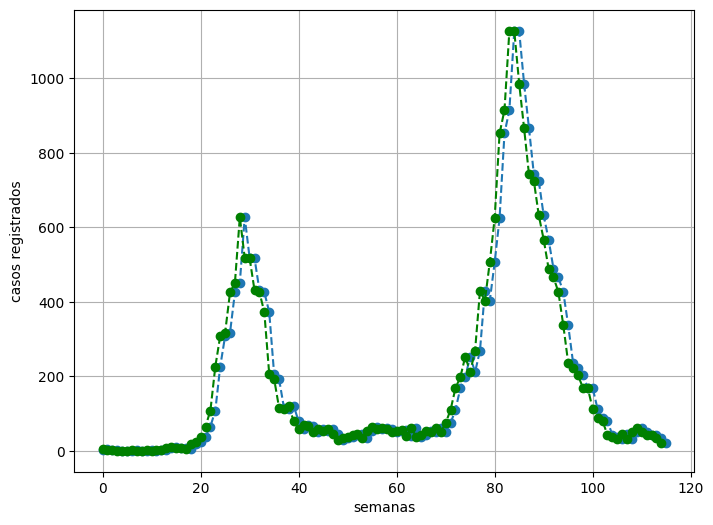

In [45]:
#Generar una única serie de tiempo
unique_series = apply_along_axis(sum,0,mat_age)
figure(figsize = (8,6))
plot(unique_series, linestyle = '--', marker = 'o')
plot(unique_series[1:], linestyle = '--', marker = 'o', color = 'green')
grid()
xlabel('semanas')
ylabel('casos registrados')

**Autocovarianza:**
$\large{\gamma_k=\frac{1}{N}\sum_{t=k+1}^N(y_t-\bar{y})(y_{t-k}-\bar{y})}$

In [14]:
resultado_acovf = acovf(unique_series)
print(resultado_acovf)

[ 67202.74516944  65224.72602851  61927.33813015  57086.55464618
  51444.64787148  45093.64983638  38336.54850163  31730.80648615
  25025.66680419  18899.84541891  12724.6083083    6944.96439032
   1537.01451218  -3229.42875182  -7430.16415315 -11086.98791656
 -14159.65821682 -16987.57851708 -19326.41298203 -21308.96184948
 -22863.78791668 -23965.89341314 -24538.11030972 -24815.03224494
 -24785.02388884 -24206.21261955 -23433.35519983 -22494.847141
 -21362.34755423 -20063.92332417 -18281.29814286 -16390.03800317
 -14442.21751866 -12867.58854722 -11337.96403476 -10042.44111267
  -9163.3836335   -8315.23132675  -7391.57374354  -6515.26254856
  -5664.90297368  -4594.98045289  -3383.62028348  -2082.65436198
   -473.58328293   1132.27837281   2994.37345602   5003.67721937
   7465.75847974  10091.86545356  12660.55135128  15305.78035244
  17464.16058725  19429.33541184  20526.51053369  21092.1001175
  20647.67439214  19468.69203778  17650.89413644  15333.92382132
  12793.0707773    9768.3088

**Autocorrelación:**
    $$\large{\hat{\gamma}(k)=\frac{\sum_{t=k+1}^N(y_t-\bar{y})(y_{t-k}-\bar{y})}{\sum_{t=1}^N(y_t-\bar{y})^2}}$$
    

<Figure size 800x600 with 0 Axes>

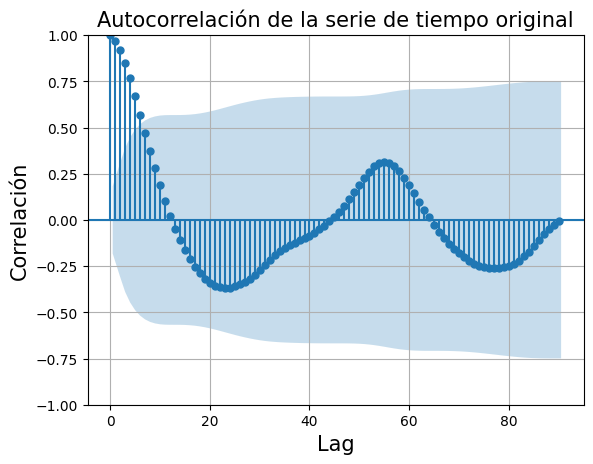

In [15]:
number_lags = 90
valores_acf = acf(unique_series, nlags=number_lags, fft=False)
#Autocorrelación de la serie de tiempo original
figure(figsize=(8,6))
sm.graphics.tsa.plot_acf(unique_series, lags=number_lags)
#axvline(x=5, linestyle="--", color= 'red')
title("Autocorrelación de la serie de tiempo original", fontsize=15)
ylabel("Correlación", fontsize=15)
xlabel("Lag", fontsize=15)
grid()
savefig("autocorr_data_USA.png", dpi=350)

In [16]:
print(argmin(valores_acf[15:25]))

8


In [17]:
print(argmax(valores_acf[45:60]))

10


Prueba estadística para la serie de tiempo del grupo etario 0-4 yr
Test Statistic           -2.695322
P-value                   0.074851
Lags Used                10.000000
No of Observations      100.000000
Critical Value (1%)      -3.497501
Critical Value (5%)      -2.890906
Critical Value (10%)     -2.582435
dtype: float64

Prueba estadística para la serie de tiempo del grupo etario 5-24 yr
Test Statistic          -3.087840
P-value                  0.027466
Lags Used               12.000000
No of Observations      98.000000
Critical Value (1%)     -3.498910
Critical Value (5%)     -2.891516
Critical Value (10%)    -2.582760
dtype: float64

Prueba estadística para la serie de tiempo del grupo etario 25-64 yr
Test Statistic           -2.825560
P-value                   0.054714
Lags Used                 5.000000
No of Observations      105.000000
Critical Value (1%)      -3.494220
Critical Value (5%)      -2.889485
Critical Value (10%)     -2.581676
dtype: float64

Prueba estadística p

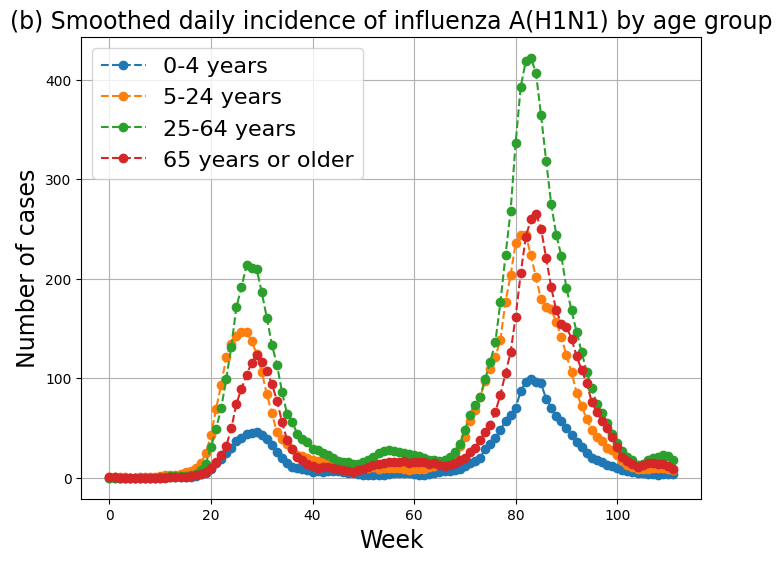

In [18]:
n_weeks_suav = n_weeks-4
#Matriz de series de tiempo suavizadas
mat_suav=zeros((4,n_weeks_suav))
for i in range(0,4):
    mat_suav[i,:] = media_movil(mat_age[i,:],k=5)

#Graficar las series de tiempo suavizadas con medias móviles de 3 semanas
#Dos de las series no son estacionarias, así que se tuvieron que diferenciar las 4
figure(figsize = (8,6))
for i in range(0,4):
    plot(mat_suav[i,:], label = groups_age_new[i], linestyle = "--", marker = "o")
    #Determinar si la serie de tiempo actual es estacionaria a través del test ADF
    dftest_act = adfuller(diff(mat_suav[i,:]), autolag='AIC')
    result_act = pd.Series(dftest_act[0:4], index=['Test Statistic','P-value','Lags Used','No of Observations'])
    for key,value in dftest_act[4].items():
        result_act['Critical Value (%s)'%key] = value
    print("Prueba estadística para la serie de tiempo del grupo etario "+str(groups_age[i]))
    print(result_act)
    print()
grid()
legend(prop={'size':16})
xlabel("Week", fontsize=17)
ylabel("Number of cases", fontsize=17)
title("(b) Smoothed daily incidence of influenza A(H1N1) by age group", fontsize=17)
savefig("Cases_influenza_smoothed.png", dpi=350)

**Diferenciando las series suavizadas se convierten todas en estacionarias**

##Porcentaje de casos registrados por cada grupo de edad

[np.float64(2164.0), np.float64(5939.0), np.float64(9016.0), np.float64(5420.0)]


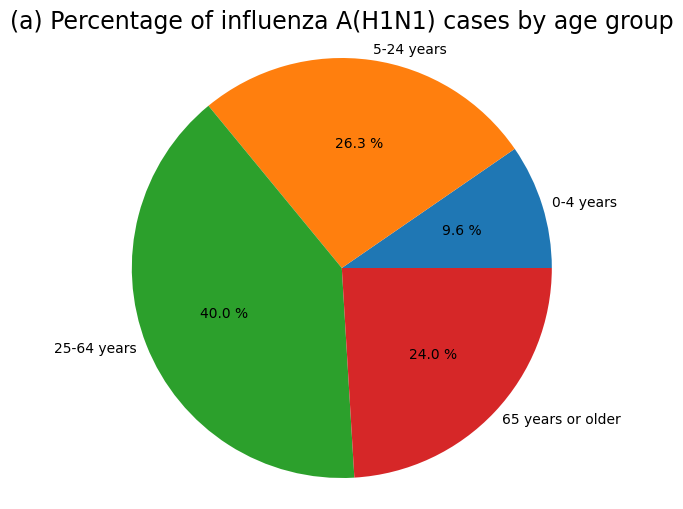

In [19]:
figure(figsize=(8,6))
#Sumar los casos por cada grupo de edad
n = 4
suma = []
for i in range(0,n):
    suma.append(sum(mat_age[i,:]))
print(suma)

#Pie chart
pie(suma, labels=groups_age_new, autopct="%0.1f %%", labeldistance=1.05)
axis("equal")

title("(a) Percentage of influenza A(H1N1) cases by age group", fontsize=17)
savefig("Percentaje_influenza_USA.png", dpi=350)

#Encontrar la partición de las series de tiempo por sincronicidad

In [20]:
#Hacer pruebas con las series de tiempo suavizadas con medias móviles
W_cor_max_act,H_max_act = mat_cor_h_sync(mat_suav,umbral=2,h_inf=0,h_sup=4,diff_param=True)
#W_cor_max_act,H_max_act = mat_cor_h_sync(mat_suav,umbral=1,h_inf=0,h_sup=4,diff_param=True)
#Generar partición con el algoritmo WeGA
u_nk_act,com_nk_act = GeNA(W_cor_max_act)
print("La partición encontrada es:")
print(com_nk_act)

La partición encontrada es:
[[0, 2, 3], [1]]


Graficar las series de tiempo agrupadas por comunidad

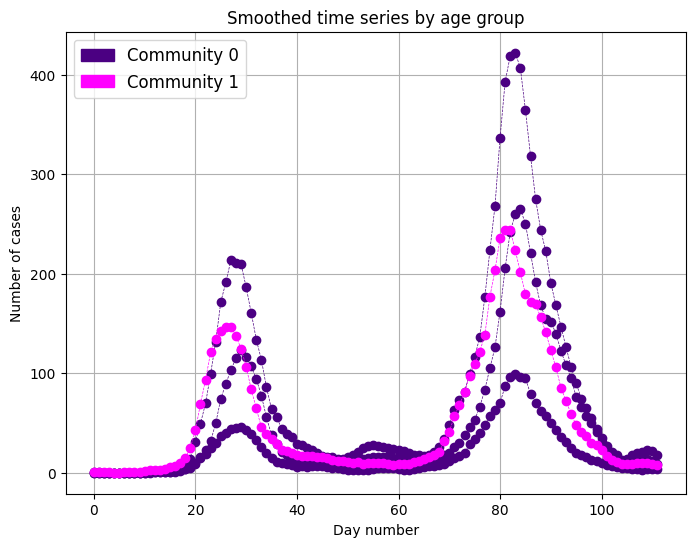

In [21]:
#El número de filas de la matriz corresponde al número de grupos y el de columnas al número de días del periodo
n1,n2 = shape(mat_suav)
#Rango de días representados
days_time_serie = arange(0,n2,1)
figure(figsize=(8,6))
grid()
title("Smoothed time series by age group")
xlabel("Day number")
ylabel("Number of cases")

#Número de comunidades
n_com = len(com_nk_act)
patches = []
#Graficar la serie de tiempo que corresponde a cada grupo
for k in range(0,n_com):
      com_act = com_nk_act[k]
      len_act = len(com_act)
      for l in range(0,len_act):
            plot(days_time_serie,mat_suav[com_act[l],:],linewidth=0.5,color=list_colors[k],linestyle="--",marker="o")
      #patch_act=mpatches.Patch(color=list_colors[k], label='Comunidad '+str(k))
      patch_act=mpatches.Patch(color=list_colors[k], label='Community '+str(k))
      patches.append(patch_act)
legend(handles=patches,prop={'size':12})
#savefig('series_tiempo_grupo_USA.png', dpi=350)
savefig('time_series_group_USA.png', dpi=600)

Nivel de pertenencia de los nodos a la comunidad

[[np.float64(0.0012324446525615721), np.float64(0.01741248532045728), np.float64(0.9813550700269812)], [np.float64(1.0)]]


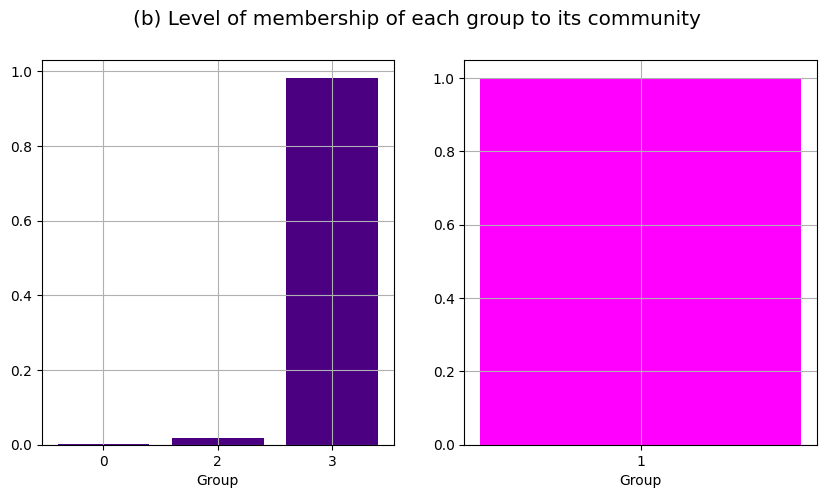

In [22]:
lev_member = level_membership_GeNA(u_nk_act)
print(lev_member)
#Histograma de nivel de pertenencia por cada comunidad
fig = figure(figsize = (10,5))
subplot(1,2,1)
grid()
#xlabel("Grupo")
xlabel("Group")
bar(list(map(str,com_nk_act[0])),lev_member[0], color = list_colors[0])
subplot(1,2,2)
grid()
#xlabel("Grupo")
xlabel("Group")
bar(list(map(str,com_nk_act[1])),lev_member[1], color = list_colors[1])

#st = fig.suptitle("(b) Nivel de pertenencia de cada grupo a su comunidad", fontsize = "x-large")
st = fig.suptitle("(b) Level of membership of each group to its community", fontsize = "x-large")
#savefig('nivel_pertenencia_edad_USA.png', dpi=350)
savefig('level_membership_USA.png', dpi=600)

Graficar series normalizadas por total de infectados

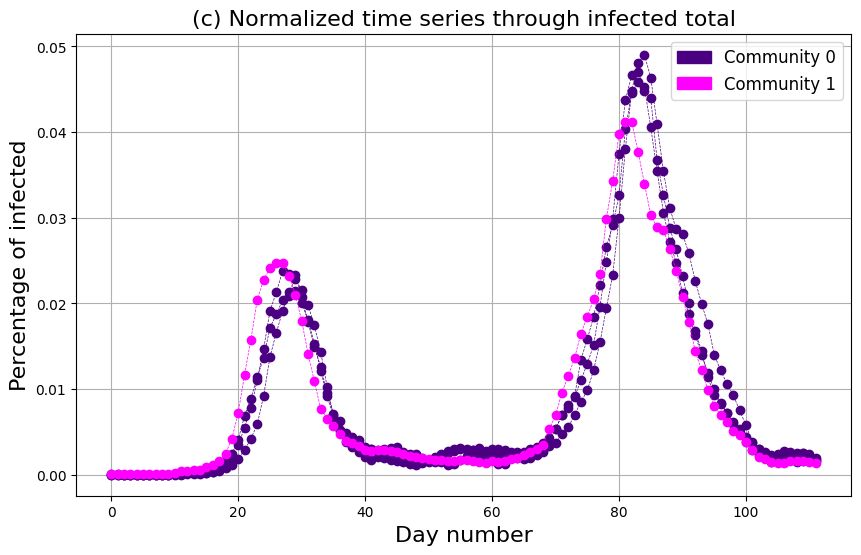

In [23]:
figure(figsize=(10,6))
grid()
'''
title("(c) Series de tiempo normalizadas de acuerdo al total de infectados", fontsize=16)
xlabel("Número de día")
ylabel("Porcentaje de infectados")
'''
title("(c) Normalized time series through infected total", fontsize=16)
xlabel("Day number", fontsize=16)
ylabel("Percentage of infected", fontsize=16)

#Número de comunidades
patches=[]
#Graficar la serie de tiempo que corresponde a cada grupo
for k in range(0,n_com):
      com_act=com_nk_act[k]
      len_act=len(com_act)
      for l in range(0,len_act):
            plot(days_time_serie,mat_suav[com_act[l],:]/sum(mat_suav[com_act[l],:]),linewidth=0.5,color=list_colors[k],linestyle="--",marker="o")
      #patch_act=mpatches.Patch(color=list_colors[k], label='Comunidad '+str(k))
      patch_act=mpatches.Patch(color=list_colors[k], label='Community '+str(k))
      patches.append(patch_act)
legend(handles=patches,prop={'size':12})
#savefig('series_edad_norm_USA.png', dpi=350)
savefig('series_age_norm_USA.png', dpi=600)

Encontrar la correlación cruzada máxima entre las comunidades encontradas a partir de sincronicidad

In [24]:
#Sumar las filas de la matriz de datos suavizados que corresponden a grupos de la misma comunidad
mat_suav_com=zeros((n_com,n_weeks_suav))
#Número de habitantes por comunidad
pop_com = zeros((n_com))
for i in range(0,n_com):
      com_act = com_nk_act[i]
      for j in range(0,len(com_act)):
          mat_suav_com[i,:]=mat_suav_com[i,:]+mat_suav[com_act[j],:]

Graficar las series de tiempo correspondientes a las dos comunidades de edades encontradas

Prueba estadística para la serie de tiempo de la comunidad 0
Test Statistic           -2.613287
P-value                   0.090282
Lags Used                10.000000
No of Observations      100.000000
Critical Value (1%)      -3.497501
Critical Value (5%)      -2.890906
Critical Value (10%)     -2.582435
dtype: float64

Prueba estadística para la serie de tiempo de la comunidad 1
Test Statistic          -3.087840
P-value                  0.027466
Lags Used               12.000000
No of Observations      98.000000
Critical Value (1%)     -3.498910
Critical Value (5%)     -2.891516
Critical Value (10%)    -2.582760
dtype: float64



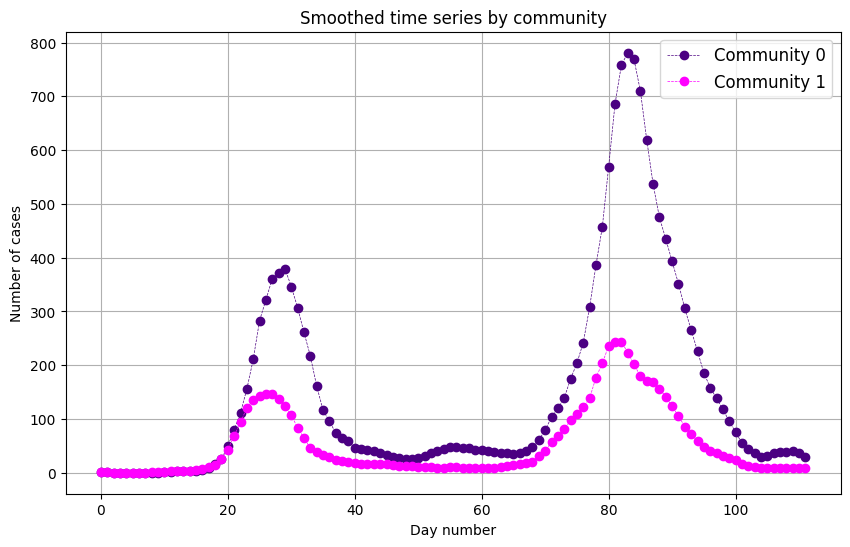

In [25]:
figure(figsize=(10,6))
grid()
title("Smoothed time series by community")
xlabel("Day number")
ylabel("Number of cases")
#Número de comunidades
n_com=len(com_nk_act)
#Graficar la serie de tiempo que corresponde a cada grupo
for k in range(0,n_com):
      plot(days_time_serie,mat_suav_com[k,:],linewidth=0.5,color=list_colors[k],linestyle="--",marker="o",label='Community '+str(k))
      #Determinar si la serie de tiempo actual es estacionaria a través del test ADF
      dftest_act = adfuller(diff(mat_suav_com[k,:]), autolag='AIC')
      result_act = pd.Series(dftest_act[0:4], index=['Test Statistic','P-value','Lags Used','No of Observations'])
      for key,value in dftest_act[4].items():
            result_act['Critical Value (%s)'%key] = value
      print("Prueba estadística para la serie de tiempo de la comunidad "+str(k))
      print(result_act)
      print()
legend(prop={'size':12})

**También se diferencian las series por comunidades para que sean estacionarias**

Graficar series normalizándolas mediante el total de infectados

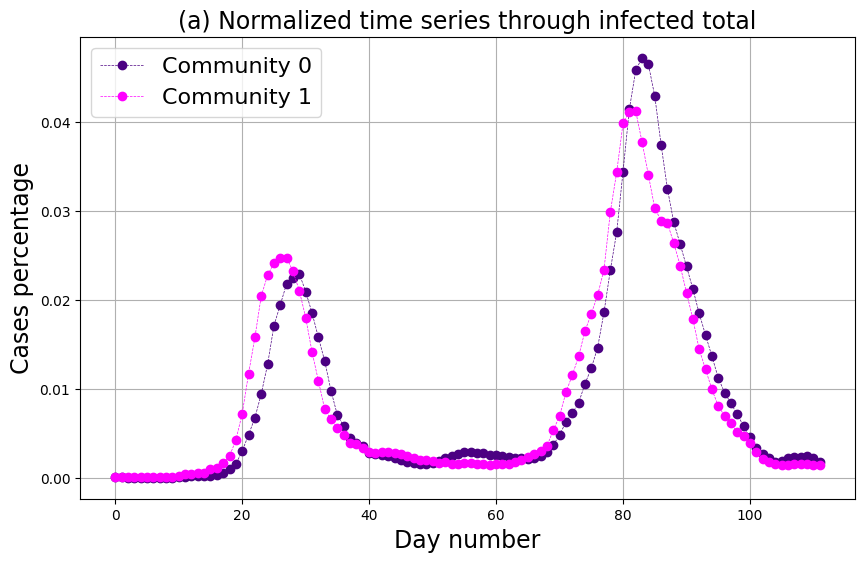

In [26]:
sum_com0 = sum(mat_suav_com[0,:])
sum_com1 = sum(mat_suav_com[1,:])
figure(figsize=(10,6))
grid()
title("(a) Normalized time series through infected total", fontsize=17)
xlabel("Day number", fontsize=17)
ylabel("Cases percentage", fontsize=17)

#Graficar la serie de tiempo que corresponde a cada grupo

plot(days_time_serie, mat_suav_com[0,:]/sum_com0, linewidth = 0.5, color = list_colors[0], linestyle = "--", marker = "o", label = 'Community 0')
plot(days_time_serie, mat_suav_com[1,:]/sum_com1, linewidth = 0.5, color = list_colors[1], linestyle = "--", marker = "o", label = 'Community 1')

legend(prop={'size':16})
savefig('series_com_norm_USA.png', dpi=350)
#savefig('series_com_norm_USA.png', dpi=600)

Representación de las interacciones entre comunidades a través de un grafo

In [27]:
h_min,h_max = 3,4
W_cor_max_part,H_new_part,A_part = constr_cor_max_dir(mat_suav_com,umbral=3,h_inf=3,h_sup=4,diff_param=True)
print(A_part)
print(H_new_part)
print(W_cor_max_part)

[[0. 1.]
 [0. 0.]]
[[0. 3.]
 [0. 0.]]
[[0.         0.87294144]
 [0.87294144 0.        ]]


**Nota importante:** Entre menos ruido presenten las series de tiempo es mejor la clasificación encontrada por el algoritmo WeGA. Para ello, en este caso se suavizó cada serie con medias móviles de 5 semanas en lugar de 3.
Y para facilitar que fueran estacionarias no se removió una parte inicial de cada serie donde los casos registrados fueron nulos o pocos.

**Verificar si esta correlación es significativa**

Analizar la autocorrelación de las series

<StemContainer object of 3 artists>

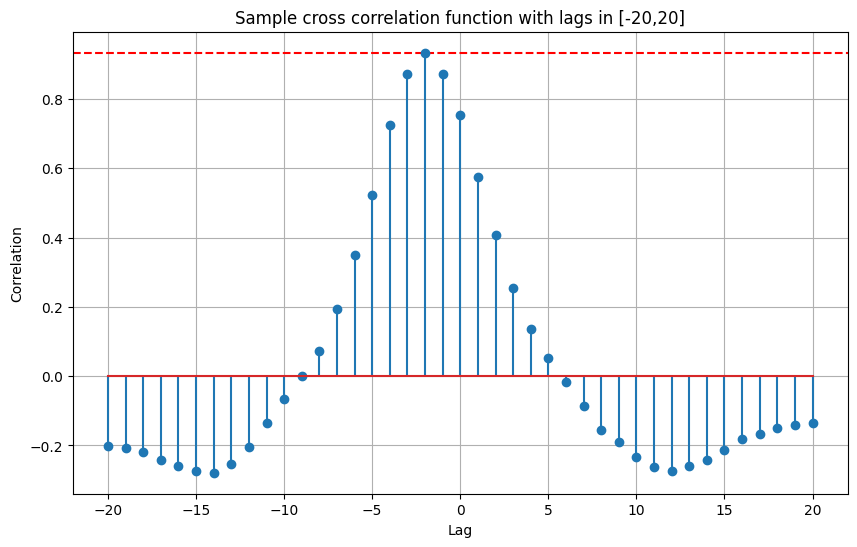

In [28]:
#Correlación cruzada entre las series de tiempo con desfases en un intervalo grande
number_lags = 20
cross_corr_lag_neg = sm.tsa.stattools.ccf(diff(mat_suav_com[0,:]),diff(mat_suav_com[1,:]), adjusted = False, nlags = number_lags+1)
cross_corr_lag_pos = sm.tsa.stattools.ccf(diff(mat_suav_com[1,:]),diff(mat_suav_com[0,:]), adjusted = False, nlags = number_lags+1)
cross_corr = zeros((2*number_lags+1))
cross_corr[0:number_lags+1] = cross_corr_lag_neg[::-1]
cross_corr[number_lags+1:2*number_lags+1] = cross_corr_lag_pos[1:]
figure(figsize=(10,6))
xlabel("Lag")
ylabel("Correlation")
title("Sample cross correlation function with lags in [-"+str(number_lags)+","+str(number_lags)+"]")
axhline(y = max(cross_corr), linestyle="--", color = 'red')
grid()
stem(range(-number_lags,number_lags+1),cross_corr)

Comparar su valor con $\frac{1.96}{\sqrt{n}}$ para rechazar la hipótesis de que es ruido blanco y, por lo tanto, no sigue una distribución $N(0,σ)$

In [29]:
p = 1.96/sqrt(len(diff(mat_suav_com[0,:])))
print("Puesto que "+str(p)+" < 0.89761231, entonces la correlación representada en el grafo es significativa")

Puesto que 0.18603496716748982 < 0.89761231, entonces la correlación representada en el grafo es significativa


Aplicar test de causalidad

In [30]:
labels_com = []
for i in range(0,n_com):
    labels_com.append("Comunidad_"+str(i))
grangers_causation_matrix(mat_suav_com, labels_com, maxlag=list(arange(h_min,h_max+1,1)))

/home/niko/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


,Comunidad_0_x,Comunidad_1_x
Comunidad_0_y,1.0000,0.0
Comunidad_1_y,0.1715,1.0


#RWTLCC

In [31]:
#Function to generate a heatmap corresponding to the RWTLCC between the series ts_1 and ts_2
def heatmap_RWTLCC(ts_1,ts_2,lab_1,lab_2):
    seconds = 2
    fps = 5
    window_size = 70 #samples
    t_start = 0
    t_end = t_start + window_size
    step_size = 5
    rss = []
    #Length of the time series
    length = len(ts_1)
    while t_end < length:
        d1 = ts_1[t_start:t_end]
        d2 = ts_2[t_start:t_end]
        cross_corr_lag_neg = sm.tsa.stattools.ccf(d1, d2, adjusted = False, nlags = int(seconds*fps+1))
        cross_corr_lag_pos = sm.tsa.stattools.ccf(d2, d1, adjusted = False, nlags = int(seconds*fps+1))
        rs = zeros((2*seconds*fps+1))
        rs[0:seconds*fps+1] = cross_corr_lag_neg[::-1]
        rs[seconds*fps+1:2*seconds*fps+1] = cross_corr_lag_pos[1:]
        rss.append(rs)
        t_start = t_start + step_size
        t_end = t_end + step_size
    rss = pd.DataFrame(rss)
    f,ax = subplots(figsize=(8,5))
    sns.heatmap(rss, cmap='RdBu_r',ax=ax)
    ax.set(title=f'RWTLCC between time series of community '+str(lab_1)+' and community '+str(lab_2) ,xlim=[0,len(rs)], xlabel='Offset',ylabel='Window epochs')
    ax.set_xticklabels(arange(-seconds*fps,seconds*fps+1,1))
    return

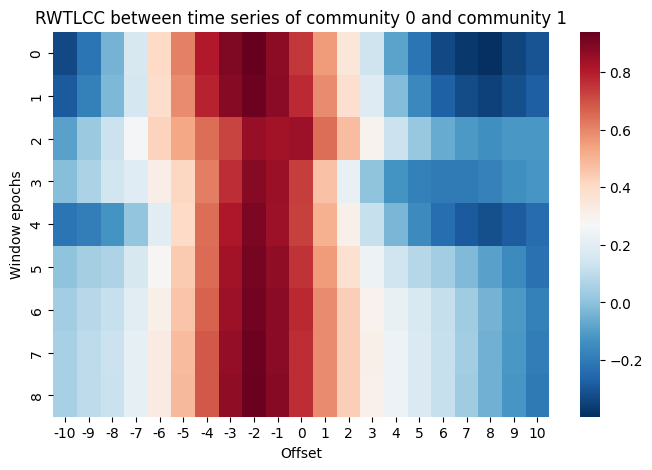

In [32]:
heatmap_RWTLCC(diff(mat_suav_com[0,:]),diff(mat_suav_com[1,:]),'0','1')